In [9]:
import sqlite3

conn = sqlite3.connect("sale_data.db")
cursor = conn.cursor()

cursor.execute("""
CREATE TABLE IF NOT EXISTS sales (
    id INTEGER PRIMARY KEY AUTOINCREMENT,
    product TEXT NOT NULL,
    quantity INTEGER NOT NULL,
    price REAL NOT NULL
)
""")

sample_data = [
    ("Laptop", 4, 800.00),
    ("Laptop", 2, 820.00),
    ("Smartphone", 10, 400.00),
    ("Smartphone", 5, 390.00),
    ("Headphones", 20, 50.00),
    ("Headphones", 15, 55.00),
    ("Monitor", 6, 150.00),
    ("Monitor", 3, 145.00)
]

cursor.executemany("INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)", sample_data)
conn.commit()
conn.close()


Sales Summary by Product:
      product  total_qty  revenue
0  Headphones         70   3650.0
1      Laptop         12   9680.0
2     Monitor         18   2670.0
3  Smartphone         30  11900.0


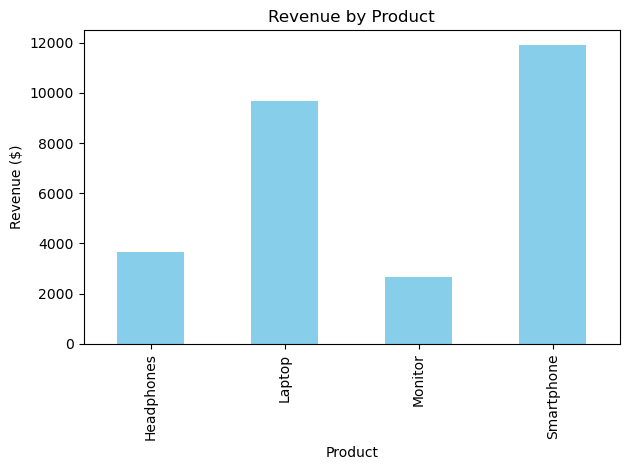

In [10]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

conn = sqlite3.connect("sale_data.db")

query = """
SELECT product, 
       SUM(quantity) AS total_qty, 
       SUM(quantity * price) AS revenue
FROM sales
GROUP BY product
"""

df = pd.read_sql_query(query, conn)

print("Sales Summary by Product:")
print(df)

df.plot(kind='bar', x='product', y='revenue', color='skyblue', legend=False)
plt.title("Revenue by Product")
plt.xlabel("Product")
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.savefig("sales_chart.png")
plt.show()

conn.close()
